# XCiT Phase 2 — Multitask Fine-tuning (Classification + Mass & pT Regression)

**Loads the XCiT encoder pretrained in Phase 1 (`best_xcit_mae.pth`).**

| | Finetune | Scratch |
|---|---|---|
| Init | MAE encoder weights | Random |
| Step 1 | Freeze backbone, train 3 heads (20 ep, LR=1e-3) | — |
| Step 2 | Unfreeze backbone at LR=3e-5, heads at LR=1e-3 (30 ep) | All params LR=1e-3 (50 ep) |
| Loss | W_CLS·CE + W_MASS·MSE + W_PT·MSE | Same |

**Data:** Run `regression_dataset.py` once on `Dataset_Specific_labelled_full_only_for_2i.h5`
to produce the `.npy` files loaded here.

## 1 · Installs

In [1]:
# !pip install torch torchvision einops h5py scikit-learn matplotlib


## 2 · Imports & device

In [2]:
import numpy as np, math, os, time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, classification_report
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps")
print(f"Device: {DEVICE}")


Device: cuda


## 3 · Hyperparameters

In [3]:
MAE_WEIGHTS = "/kaggle/input/models/abhirajraje/best-l2vit/pytorch/default/4/best_xcit_mae.pth"
MT_DIR      = "/kaggle/input/datasets/abhirajraje/jet-data-vit"
BATCH_SIZE  = 64
NUM_WORKERS = 2

EPOCHS_FROZEN   = 20
EPOCHS_FINETUNE = 30
EPOCHS_SCRATCH  = 50
LR_HEAD         = 1e-3
LR_BACKBONE_FT  = 5e-5
LR_SCRATCH      = 1e-3
WEIGHT_DECAY    = 1e-2
WARMUP_EPOCHS   = 5

W_CLS  = 2.0
W_MASS = 1.0
W_PT   = 1.0

IMAGE_SIZE  = 125
PATCH_SIZE  = 5
IN_CHANNELS = 8
NUM_CLASSES = 2
DIM         = 192
DEPTH       = 8
NUM_HEADS   = 8
MLP_RATIO   = 4
CLS_DEPTH   = 2
DROPOUT     = 0.2
DROP_PATH   = 0.05

print(f"Backbone dim={DIM} depth={DEPTH} heads={NUM_HEADS}")
print(f"Fine-tune: freeze {EPOCHS_FROZEN}ep backbone={LR_BACKBONE_FT} heads={LR_HEAD}")


Backbone dim=192 depth=8 heads=8
Fine-tune: freeze 20ep backbone=5e-05 heads=0.001


## 4 · XCiT Building Blocks (identical to Phase 1)
These must not be modified — key names must match `XCiTEncoder` in Phase 1 exactly.

In [4]:
class DropPath(nn.Module):
    def __init__(self, p=0.0):
        super().__init__(); self.p = p
    def forward(self, x):
        if not self.training or self.p == 0.0: return x
        keep = 1 - self.p
        mask = (torch.rand((x.shape[0],)+(1,)*(x.ndim-1), device=x.device)<keep).float()
        return x * mask / keep

class XCA(nn.Module):
    def __init__(self, dim, num_heads=8, qkv_bias=False, dropout=0.0):
        super().__init__()
        self.num_heads   = num_heads
        self.head_dim    = dim // num_heads
        self.temperature = nn.Parameter(torch.ones(num_heads, 1, 1))
        self.qkv  = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.proj = nn.Sequential(nn.Linear(dim, dim), nn.Dropout(dropout))
    def forward(self, x):
        B, N, C = x.shape; h = self.num_heads
        qkv = self.qkv(x).reshape(B,N,3,h,C//h).permute(2,0,3,1,4).contiguous()
        q,k,v = qkv[0],qkv[1],qkv[2]
        q = F.normalize(q.transpose(-2,-1).contiguous(), dim=-1, p=2)
        k = F.normalize(k.transpose(-2,-1).contiguous(), dim=-1, p=2)
        v = v.transpose(-2,-1).contiguous()
        attn = (k @ q.transpose(-2,-1).contiguous()) * self.temperature
        out  = (attn.softmax(dim=-1) @ v).permute(0,3,1,2).contiguous().reshape(B,N,C)
        return self.proj(out)

class LPI(nn.Module):
    def __init__(self, dim, kernel_size=3):
        super().__init__()
        pad = kernel_size // 2
        self.net = nn.Sequential(
            nn.Conv2d(dim,dim,kernel_size,padding=pad,groups=dim,bias=False),
            nn.GELU(), nn.BatchNorm2d(dim),
            nn.Conv2d(dim,dim,kernel_size,padding=pad,groups=dim,bias=False))
    def forward(self, x, H, W):
        B,N,C = x.shape
        return self.net(x.transpose(1,2).contiguous().view(B,C,H,W)).flatten(2).transpose(1,2).contiguous()

class XCiTBlock(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4, dropout=0.0, drop_path=0.0):
        super().__init__()
        self.norm1=nn.LayerNorm(dim); self.norm2=nn.LayerNorm(dim); self.norm3=nn.LayerNorm(dim)
        self.xca=XCA(dim,num_heads=num_heads,dropout=dropout); self.lpi=LPI(dim)
        self.ffn=nn.Sequential(nn.Linear(dim,dim*mlp_ratio),nn.GELU(),nn.Dropout(dropout),
                               nn.Linear(dim*mlp_ratio,dim),nn.Dropout(dropout))
        self.drop_path=DropPath(drop_path) if drop_path>0 else nn.Identity()
    def forward(self, x, H, W):
        x = x + self.drop_path(self.xca(self.norm1(x)))
        x = x + self.drop_path(self.lpi(self.norm2(x),H,W))
        x = x + self.drop_path(self.ffn(self.norm3(x)))
        return x

class ClassAttention(nn.Module):
    def __init__(self, dim, num_heads=8):
        super().__init__()
        self.num_heads=num_heads; self.scale=(dim//num_heads)**-0.5
        self.q=nn.Linear(dim,dim); self.kv=nn.Linear(dim,dim*2); self.proj=nn.Linear(dim,dim)
    def forward(self, x):
        B,N,C=x.shape; h=self.num_heads
        q  = self.q(x[:,:1]).reshape(B,1,h,C//h).permute(0,2,1,3).contiguous()
        kv = self.kv(x).reshape(B,N,2,h,C//h).permute(2,0,3,1,4).contiguous()
        k,v = kv[0],kv[1]
        attn = (q @ k.transpose(-2,-1).contiguous()) * self.scale
        out  = (attn.softmax(dim=-1) @ v).transpose(1,2).contiguous().reshape(B,1,C)
        return torch.cat([self.proj(out), x[:,1:]], dim=1)

class ClassAttentionBlock(nn.Module):
    def __init__(self, dim, num_heads):
        super().__init__()
        self.norm1=nn.LayerNorm(dim); self.norm2=nn.LayerNorm(dim)
        self.attn=ClassAttention(dim,num_heads)
        self.ffn=nn.Sequential(nn.Linear(dim,dim*4),nn.GELU(),nn.Linear(dim*4,dim))
    def forward(self, x):
        x=x+self.attn(self.norm1(x))
        return torch.cat([x[:,:1]+self.ffn(self.norm2(x[:,:1])), x[:,1:]], dim=1)

class SinCos2DPosEmb(nn.Module):
    def __init__(self, dim, temperature=10000):
        super().__init__(); assert dim%4==0
        self.temperature=temperature; self.proj=nn.Linear(64,dim)
    def forward(self, H, W, device):
        y_pos=torch.arange(H,device=device).unsqueeze(1).float()
        x_pos=torch.arange(W,device=device).unsqueeze(1).float()
        omega=1.0/(self.temperature**(torch.arange(16,device=device).float()/16))
        y_enc=torch.cat([torch.sin(y_pos*omega),torch.cos(y_pos*omega)],dim=-1)
        x_enc=torch.cat([torch.sin(x_pos*omega),torch.cos(x_pos*omega)],dim=-1)
        pos=torch.cat([y_enc.unsqueeze(1).expand(H,W,32),
                       x_enc.unsqueeze(0).expand(H,W,32)],dim=-1).reshape(H*W,64)
        return self.proj(pos)

print("Building blocks defined.")


Building blocks defined.


## 5 · XCiTMultitask Model
Backbone key names exactly match `XCiTEncoder` from Phase 1.
`head_cls`, `head_mass`, `head_pt` are new and randomly initialised.

In [5]:
class XCiTMultitask(nn.Module):
    def __init__(self,
                 image_size=IMAGE_SIZE, patch_size=PATCH_SIZE,
                 in_channels=IN_CHANNELS, num_classes=NUM_CLASSES,
                 dim=DIM, depth=DEPTH, num_heads=NUM_HEADS,
                 mlp_ratio=MLP_RATIO, cls_depth=CLS_DEPTH,
                 dropout=DROPOUT, drop_path=DROP_PATH):
        super().__init__()
        self.patch_size = patch_size
        self.H = self.W = image_size // patch_size

        self.patch_embed = nn.Conv2d(in_channels, dim, kernel_size=patch_size, stride=patch_size)
        self.emb_norm    = nn.LayerNorm(dim)
        self.pos_emb     = SinCos2DPosEmb(dim)

        dpr = [x.item() for x in torch.linspace(0, drop_path, depth)]
        self.blocks = nn.ModuleList([XCiTBlock(dim,num_heads,mlp_ratio,dropout,dpr[i]) for i in range(depth)])
        self.norm   = nn.LayerNorm(dim)

        self.cls_token  = nn.Parameter(torch.zeros(1,1,dim))
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        self.cls_blocks = nn.ModuleList([ClassAttentionBlock(dim,num_heads) for _ in range(cls_depth)])
        self.cls_norm   = nn.LayerNorm(dim)

        self.head_cls  = nn.Linear(dim, num_classes)
        self.head_mass = nn.Sequential(nn.Linear(dim,dim//2),nn.GELU(),nn.Dropout(0.1),nn.Linear(dim//2,1))
        self.head_pt   = nn.Sequential(nn.Linear(dim,dim//2),nn.GELU(),nn.Dropout(0.1),nn.Linear(dim//2,1))
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, (nn.LayerNorm, nn.BatchNorm2d)):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def _backbone_params(self):
        head_ids = {id(p) for h in [self.head_cls,self.head_mass,self.head_pt] for p in h.parameters()}
        return [p for p in self.parameters() if id(p) not in head_ids]

    def head_params(self):
        return [p for h in [self.head_cls,self.head_mass,self.head_pt] for p in h.parameters()]

    def freeze_backbone(self):
        for p in self._backbone_params(): p.requires_grad_(False)
        self.cls_token.requires_grad_(False)
        print(f"Backbone frozen ({sum(p.numel() for p in self._backbone_params()):,} params).")

    def unfreeze_backbone(self):
        for p in self._backbone_params(): p.requires_grad_(True)
        self.cls_token.requires_grad_(True)
        print("Backbone unfrozen.")

    def forward(self, x):
        B  = x.shape[0]
        ps = self.patch_size
        H, W = self.H, self.W
        pad_h = (ps - x.shape[2] % ps) % ps
        pad_w = (ps - x.shape[3] % ps) % ps
        if pad_h or pad_w: x = F.pad(x,(0,pad_w,0,pad_h))

        x = self.patch_embed(x).flatten(2).transpose(1,2).contiguous()
        x = self.emb_norm(x + self.pos_emb(H,W,x.device).unsqueeze(0))
        for blk in self.blocks: x = blk(x,H,W)
        x = self.norm(x)

        cls = self.cls_token.expand(B,-1,-1)
        x   = torch.cat([cls,x],dim=1)
        for blk in self.cls_blocks: x = blk(x)
        feat = self.cls_norm(x)[:,0]

        return self.head_cls(feat), self.head_mass(feat).squeeze(-1), self.head_pt(feat).squeeze(-1)

_m=XCiTMultitask().to(DEVICE)
_x=torch.randn(2,IN_CHANNELS,IMAGE_SIZE,IMAGE_SIZE,device=DEVICE)
_lg,_mp,_pp=_m(_x)
n_tot=sum(p.numel() for p in _m.parameters())
n_h=sum(p.numel() for p in _m.head_params())
print(f"Forward OK  logits={_lg.shape}  mass={_mp.shape}  pt={_pp.shape}")
print(f"Params: total={n_tot:,}  backbone={n_tot-n_h:,}  heads={n_h:,}")
del _m,_x


Forward OK  logits=torch.Size([2, 2])  mass=torch.Size([2])  pt=torch.Size([2])
Params: total=4,567,940  backbone=4,530,304  heads=37,636


## 6 · Dataset & Loaders

In [6]:
class JetDatasetMT(Dataset):
    def __init__(self, X, y, mass, pt):
        self.X    = torch.from_numpy(X).float().permute(0,3,1,2)
        self.y    = torch.from_numpy(y).long()
        self.mass = torch.from_numpy(mass).float()
        self.pt   = torch.from_numpy(pt).float()
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i], self.mass[i], self.pt[i]

def make_loaders_mt(X_tr,y_tr,m_tr,p_tr,X_te,y_te,m_te,p_te):
    tr=DataLoader(JetDatasetMT(X_tr,y_tr,m_tr,p_tr),BATCH_SIZE,shuffle=True, num_workers=NUM_WORKERS,pin_memory=True)
    te=DataLoader(JetDatasetMT(X_te,y_te,m_te,p_te),BATCH_SIZE,shuffle=False,num_workers=NUM_WORKERS,pin_memory=True)
    return tr, te


## 7 · Multitask Loss

In [7]:
def multitask_loss(logits, mp, pp, y, m_true, p_true, cls_crit):
    l_cls  = cls_crit(logits, y)
    l_mass = F.mse_loss(mp, m_true)
    l_pt   = F.mse_loss(pp, p_true)
    return W_CLS*l_cls + W_MASS*l_mass + W_PT*l_pt, l_cls, l_mass, l_pt


## 8 · Training & Evaluation Loops

In [8]:
def train_epoch_mt(model, loader, cls_crit, opt, scaler):
    model.train()
    tot={"loss":0,"cls":0,"mass":0,"pt":0,"correct":0,"n":0}
    nb=len(loader)
    for i,(X,y,mass,pt) in enumerate(loader):
        X,y,mass,pt=X.to(DEVICE),y.to(DEVICE),mass.to(DEVICE),pt.to(DEVICE)
        opt.zero_grad()
        with torch.amp.autocast(DEVICE.type, enabled=(DEVICE.type=="cuda")):
            lg,mp,pp=model(X)
            loss,lc,lm,lp=multitask_loss(lg,mp,pp,y,mass,pt,cls_crit)
        scaler.scale(loss).backward()
        nn.utils.clip_grad_norm_(model.parameters(), 0.5)
        scaler.step(opt); scaler.update()
        bs=len(y)
        tot["loss"]+=loss.item()*bs; tot["cls"]+=lc.item()*bs
        tot["mass"]+=lm.item()*bs;   tot["pt"]+=lp.item()*bs
        tot["correct"]+=(lg.argmax(1)==y).sum().item(); tot["n"]+=bs
        bar="█"*int(30*(i+1)/nb)+"░"*(30-int(30*(i+1)/nb))
        print(f"\r  [{bar}] {i+1}/{nb}  loss={tot['loss']/tot['n']:.4f}",end="",flush=True)
    print()
    n=tot["n"]
    return tot["loss"]/n,tot["cls"]/n,tot["mass"]/n,tot["pt"]/n,tot["correct"]/n

@torch.no_grad()
def eval_epoch_mt(model, loader, cls_crit, norm_stats):
    model.eval()
    mm,ms,pm,ps_std=norm_stats
    tot={"loss":0,"cls":0,"mass":0,"pt":0,"correct":0,"n":0}
    ps_all,ls_all,mp_all,mt_all,pp_all,pt_all=[],[],[],[],[],[]
    for X,y,mass,pt in loader:
        X,y,mass,pt=X.to(DEVICE),y.to(DEVICE),mass.to(DEVICE),pt.to(DEVICE)
        lg,mp,pp=model(X)
        loss,lc,lm,lp=multitask_loss(lg,mp,pp,y,mass,pt,cls_crit)
        bs=len(y)
        tot["loss"]+=loss.item()*bs; tot["cls"]+=lc.item()*bs
        tot["mass"]+=lm.item()*bs;   tot["pt"]+=lp.item()*bs
        tot["correct"]+=(lg.argmax(1)==y).sum().item(); tot["n"]+=bs
        ps_all.append(lg.softmax(-1).cpu().numpy())
        ls_all.append(y.cpu().numpy())
        mp_all.append(mp.cpu().numpy()*ms+mm); mt_all.append(mass.cpu().numpy()*ms+mm)
        pp_all.append(pp.cpu().numpy()*ps_std+pm); pt_all.append(pt.cpu().numpy()*ps_std+pm)
    ps_all=np.concatenate(ps_all); ls_all=np.concatenate(ls_all)
    mp_g=np.concatenate(mp_all);   mt_g=np.concatenate(mt_all)
    pp_g=np.concatenate(pp_all);   pt_g=np.concatenate(pt_all)
    try:    auc=roc_auc_score(ls_all,ps_all[:,1])
    except: auc=0.5
    n=tot["n"]
    return (tot["loss"]/n,tot["cls"]/n,tot["mass"]/n,tot["pt"]/n,
            tot["correct"]/n,auc,
            np.abs(mp_g-mt_g).mean(),np.abs(pp_g-pt_g).mean(),
            ps_all,ls_all,mp_g,mt_g,pp_g,pt_g)


## 9 · Load Data

In [9]:
X_train    = np.load(f"{MT_DIR}/X_train_mt.npy")
X_test     = np.load(f"{MT_DIR}/X_test_mt.npy")
y_train    = np.load(f"{MT_DIR}/y_train_mt.npy")
y_test     = np.load(f"{MT_DIR}/y_test_mt.npy")
mass_train = np.load(f"{MT_DIR}/mass_train_norm.npy")
mass_test  = np.load(f"{MT_DIR}/mass_test_norm.npy")
pt_train   = np.load(f"{MT_DIR}/pt_train_norm.npy")
pt_test    = np.load(f"{MT_DIR}/pt_test_norm.npy")
norm_stats = np.load(f"{MT_DIR}/norm_stats.npy")
mass_mean, mass_std, pt_mean, pt_std = norm_stats

print(f"X_train    : {X_train.shape}")
print(f"y_train    : {y_train.shape}  classes={list(np.unique(y_train))}")
print(f"mass_train : mean={mass_train.mean():.3f}  std={mass_train.std():.3f}  (z-scored)")
print(f"pt_train   : mean={pt_train.mean():.3f}  std={pt_train.std():.3f}  (z-scored)")
print(f"norm stats : mass={mass_mean:.2f}+/-{mass_std:.2f} GeV  pT={pt_mean:.2f}+/-{pt_std:.2f} GeV")

pos_w = float((y_train==0).sum() / (y_train==1).sum())
cls_crit = nn.CrossEntropyLoss(weight=torch.tensor([1.0, pos_w]).to(DEVICE))

train_loader, test_loader = make_loaders_mt(
    X_train, y_train, mass_train, pt_train,
    X_test,  y_test,  mass_test,  pt_test)
print(f"Train batches={len(train_loader)}  Test batches={len(test_loader)}")


X_train    : (8000, 125, 125, 8)
y_train    : (8000,)  classes=[np.int64(0), np.int64(1)]
mass_train : mean=-0.000  std=1.000  (z-scored)
pt_train   : mean=-0.000  std=1.000  (z-scored)
norm stats : mass=142.78+/-51.51 GeV  pT=521.44+/-109.67 GeV
Train batches=125  Test batches=32


## 10 · Phase 2a — Load MAE Weights & Build Finetune Model
The MAE encoder `state_dict` maps directly onto this model's backbone keys.
Only `head_cls`, `head_mass`, `head_pt` will appear in `missing_keys` — that is expected.

In [10]:
model_ft = XCiTMultitask().to(DEVICE)

state = torch.load(MAE_WEIGHTS, map_location=DEVICE)


# The MAE encoder saved keys like "patch_embed.weight", "blocks.0.xca.qkv.weight", etc.
# These match XCiTMultitask's top-level keys directly — no remapping needed.
missing, unexpected = model_ft.load_state_dict(state, strict=False)

print("MAE encoder weights loaded.")
print(f"  Missing keys  (should be heads only): {[k for k in missing if 'head' in k]}")
print(f"  Unexpected keys : {unexpected}")

n_total  = sum(p.numel() for p in model_ft.parameters())
n_heads  = sum(p.numel() for p in model_ft.head_params())
print(f"\nTotal params : {n_total:,}  |  Backbone : {n_total-n_heads:,}  |  Heads : {n_heads:,}")
scaler_ft = torch.amp.GradScaler(enabled=(DEVICE.type=="cuda"))


MAE encoder weights loaded.
  Missing keys  (should be heads only): ['head_cls.weight', 'head_cls.bias', 'head_mass.0.weight', 'head_mass.0.bias', 'head_mass.3.weight', 'head_mass.3.bias', 'head_pt.0.weight', 'head_pt.0.bias', 'head_pt.3.weight', 'head_pt.3.bias']
  Unexpected keys : ['mask_token']

Total params : 4,567,940  |  Backbone : 4,530,304  |  Heads : 37,636


## 11 · Step 1 — Heads-only Warm-up (Backbone Frozen)
Train only the three heads while keeping the MAE-pretrained backbone frozen.
This lets the randomly-initialised heads converge before the backbone is allowed to move.

In [11]:
model_ft.freeze_backbone()

opt1   = optim.AdamW(model_ft.head_params(), lr=LR_HEAD, weight_decay=WEIGHT_DECAY)
def _lr(ep, warmup, total):
    if ep < warmup: return (ep+1)/warmup
    return 0.5*(1+math.cos(math.pi*(ep-warmup)/max(1,total-warmup)))
sched1 = optim.lr_scheduler.LambdaLR(opt1, lambda ep: _lr(ep,WARMUP_EPOCHS,EPOCHS_FROZEN))

hist_ft = {k:[] for k in ["loss","cls","mass_mse","pt_mse","acc","auc","mass_mae","pt_mae"]}
best_auc_ft, best_ep_ft = 0.0, 0

print(f"{'Ep':>4} {'Loss':>8} {'Cls':>7} {'MassMSE':>9} {'PtMSE':>8} {'Acc':>7} {'AUC':>7} {'MassMAE':>9} {'PtMAE':>8}")
print("="*75)

for ep in range(1, EPOCHS_FROZEN+1):
    t0=time.time()
    print(f"Epoch {ep}/{EPOCHS_FROZEN} [heads only]")
    tr=train_epoch_mt(model_ft,train_loader,cls_crit,opt1,scaler_ft)
    va=eval_epoch_mt(model_ft,test_loader,cls_crit,norm_stats)
    sched1.step()
    loss,cls,mmse,pmse,acc=tr
    _,_,_,_,_,auc,mmae,pmae,*_=va
    for k,v in zip(hist_ft,[loss,cls,mmse,pmse,acc,auc,mmae,pmae]): hist_ft[k].append(v)
    flag=" *** BEST" if auc>best_auc_ft else ""
    print(f"{ep:>4} {loss:>8.4f} {cls:>7.4f} {mmse:>9.4f} {pmse:>8.4f} {acc:>7.4f} {auc:>7.4f} {mmae:>7.2f}GeV {pmae:>6.2f}GeV {time.time()-t0:.1f}s{flag}")
    if auc>best_auc_ft:
        best_auc_ft,best_ep_ft=auc,ep
        torch.save(model_ft.state_dict(),"best_xcit_mt_ft.pth")

print(f"\nStep 1 done. Best AUC={best_auc_ft:.4f} at epoch {best_ep_ft}")


Backbone frozen (4,530,304 params).
  Ep     Loss     Cls   MassMSE    PtMSE     Acc     AUC   MassMAE    PtMAE
Epoch 1/20 [heads only]
  [██████████████████████████████] 125/125  loss=3.3048
   1   3.3048  0.6700    0.9649   0.9998  0.6466  0.8472   40.15GeV  74.90GeV 22.4s *** BEST
Epoch 2/20 [heads only]
  [██████████████████████████████] 125/125  loss=2.9259
   2   2.9259  0.6153    0.6966   0.9988  0.7396  0.8554   28.35GeV  73.76GeV 21.5s *** BEST
Epoch 3/20 [heads only]
  [██████████████████████████████] 125/125  loss=2.7089
   3   2.7089  0.5681    0.5740   0.9988  0.7599  0.8573   27.82GeV  73.95GeV 22.0s *** BEST
Epoch 4/20 [heads only]
  [██████████████████████████████] 125/125  loss=2.6323
   4   2.6323  0.5339    0.5688   0.9957  0.7625  0.8585   27.64GeV  73.55GeV 22.8s *** BEST
Epoch 5/20 [heads only]
  [██████████████████████████████] 125/125  loss=2.5801
   5   2.5801  0.5157    0.5547   0.9939  0.7625  0.8595   27.58GeV  73.76GeV 23.7s *** BEST
Epoch 6/20 [heads only]

## 12 · Step 2 — Full Fine-tuning (Backbone Unfrozen at Low LR)
The backbone is **not** frozen — it is updated at `LR_BACKBONE_FT = 3e-5`,
which is 30x lower than the head LR. This is true fine-tuning.

In [12]:
model_ft.unfreeze_backbone()

no_decay = {"bias","LayerNorm.weight","LayerNorm.bias","norm.weight","norm.bias","temperature"}
head_ids = {id(p) for p in model_ft.head_params()}

opt2 = optim.AdamW([
    # Backbone — weight-decay params
    {"params":[p for n,p in model_ft.named_parameters()
               if id(p) not in head_ids and not any(nd in n for nd in no_decay)],
     "lr":LR_BACKBONE_FT, "weight_decay":WEIGHT_DECAY},
    # Backbone — no-decay params
    {"params":[p for n,p in model_ft.named_parameters()
               if id(p) not in head_ids and     any(nd in n for nd in no_decay)],
     "lr":LR_BACKBONE_FT, "weight_decay":0.0},
    # Heads — higher LR
    {"params":model_ft.head_params(), "lr":LR_HEAD, "weight_decay":WEIGHT_DECAY},
], betas=(0.9, 0.999))
sched2 = optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=EPOCHS_FINETUNE)

print(f"{'Ep':>4} {'Loss':>8} {'Cls':>7} {'MassMSE':>9} {'PtMSE':>8} {'Acc':>7} {'AUC':>7} {'MassMAE':>9} {'PtMAE':>8}")
print("="*75)

for ep in range(1, EPOCHS_FINETUNE+1):
    t0=time.time()
    print(f"Epoch {ep}/{EPOCHS_FINETUNE} [end-to-end]")
    tr=train_epoch_mt(model_ft,train_loader,cls_crit,opt2,scaler_ft)
    va=eval_epoch_mt(model_ft,test_loader,cls_crit,norm_stats)
    sched2.step()
    loss,cls,mmse,pmse,acc=tr
    _,_,_,_,_,auc,mmae,pmae,*_=va
    for k,v in zip(hist_ft,[loss,cls,mmse,pmse,acc,auc,mmae,pmae]): hist_ft[k].append(v)
    flag=" *** BEST" if auc>best_auc_ft else ""
    print(f"{ep:>4} {loss:>8.4f} {cls:>7.4f} {mmse:>9.4f} {pmse:>8.4f} {acc:>7.4f} {auc:>7.4f} {mmae:>7.2f}GeV {pmae:>6.2f}GeV {time.time()-t0:.1f}s{flag}")
    if auc>best_auc_ft:
        best_auc_ft,best_ep_ft=auc,ep
        torch.save(model_ft.state_dict(),"best_xcit_mt_ft.pth")

print(f"\nFine-tune done. Best AUC={best_auc_ft:.4f} at epoch {best_ep_ft}")


Backbone unfrozen.
  Ep     Loss     Cls   MassMSE    PtMSE     Acc     AUC   MassMAE    PtMAE
Epoch 1/30 [end-to-end]
  [██████████████████████████████] 125/125  loss=4.6362
   1   4.6362  0.8113    2.0064   1.0072  0.7275  0.9068   31.56GeV  75.71GeV 54.9s *** BEST
Epoch 2/30 [end-to-end]
  [██████████████████████████████] 125/125  loss=2.4117
   2   2.4117  0.4350    0.5476   0.9941  0.8177  0.9133  140.60GeV  79.88GeV 53.8s *** BEST
Epoch 3/30 [end-to-end]
  [██████████████████████████████] 125/125  loss=2.3736
   3   2.3736  0.4120    0.5611   0.9885  0.8316  0.9242   31.73GeV  76.09GeV 53.8s *** BEST
Epoch 4/30 [end-to-end]
  [██████████████████████████████] 125/125  loss=2.1741
   4   2.1741  0.3750    0.4420   0.9820  0.8468  0.9208   46.30GeV  83.24GeV 53.8s
Epoch 5/30 [end-to-end]
  [██████████████████████████████] 125/125  loss=2.0209
   5   2.0209  0.3496    0.4061   0.9156  0.8579  0.9331   22.84GeV 104.01GeV 54.0s *** BEST
Epoch 6/30 [end-to-end]
  [██████████████████████

## 13 · Phase 2b — Scratch Baseline

In [13]:
model_sc = XCiTMultitask().to(DEVICE)
n=sum(p.numel() for p in model_sc.parameters())
print(f"Scratch model params: {n:,}")

no_decay={"bias","LayerNorm.weight","LayerNorm.bias","norm.weight","norm.bias","temperature"}
opt_sc=optim.AdamW([
    {"params":[p for nm,p in model_sc.named_parameters() if not any(nd in nm for nd in no_decay)],
     "weight_decay":WEIGHT_DECAY,"lr":LR_SCRATCH},
    {"params":[p for nm,p in model_sc.named_parameters() if     any(nd in nm for nd in no_decay)],
     "weight_decay":0.0,"lr":LR_SCRATCH},
])
sched_sc=optim.lr_scheduler.LambdaLR(opt_sc,lambda ep:_lr(ep,WARMUP_EPOCHS,EPOCHS_SCRATCH))
scaler_sc=torch.amp.GradScaler(enabled=(DEVICE.type=="cuda"))

hist_sc={k:[] for k in ["loss","cls","mass_mse","pt_mse","acc","auc","mass_mae","pt_mae"]}
best_auc_sc,best_ep_sc=0.0,0

print(f"{'Ep':>4} {'Loss':>8} {'Cls':>7} {'MassMSE':>9} {'PtMSE':>8} {'Acc':>7} {'AUC':>7} {'MassMAE':>9} {'PtMAE':>8}")
print("="*75)

for ep in range(1, EPOCHS_SCRATCH+1):
    t0=time.time()
    print(f"Epoch {ep}/{EPOCHS_SCRATCH} [scratch]")
    tr=train_epoch_mt(model_sc,train_loader,cls_crit,opt_sc,scaler_sc)
    va=eval_epoch_mt(model_sc,test_loader,cls_crit,norm_stats)
    sched_sc.step()
    loss,cls,mmse,pmse,acc=tr
    _,_,_,_,_,auc,mmae,pmae,*_=va
    for k,v in zip(hist_sc,[loss,cls,mmse,pmse,acc,auc,mmae,pmae]): hist_sc[k].append(v)
    flag=" *** BEST" if auc>best_auc_sc else ""
    print(f"{ep:>4} {loss:>8.4f} {cls:>7.4f} {mmse:>9.4f} {pmse:>8.4f} {acc:>7.4f} {auc:>7.4f} {mmae:>7.2f}GeV {pmae:>6.2f}GeV {time.time()-t0:.1f}s{flag}")
    if auc>best_auc_sc:
        best_auc_sc,best_ep_sc=auc,ep
        torch.save(model_sc.state_dict(),"best_xcit_mt_sc.pth")

print(f"\nScratch done. Best AUC={best_auc_sc:.4f} at epoch {best_ep_sc}")


Scratch model params: 4,567,940
  Ep     Loss     Cls   MassMSE    PtMSE     Acc     AUC   MassMAE    PtMAE
Epoch 1/50 [scratch]
  [██████████████████████████████] 125/125  loss=2.9763
   1   2.9763  0.5904    0.7961   0.9994  0.6821  0.8817   27.89GeV  74.75GeV 54.1s *** BEST
Epoch 2/50 [scratch]
  [██████████████████████████████] 125/125  loss=2.3489
   2   2.3489  0.4241    0.5003   1.0005  0.8259  0.9368   23.08GeV  74.46GeV 54.1s *** BEST
Epoch 3/50 [scratch]
  [██████████████████████████████] 125/125  loss=2.1790
   3   2.1790  0.3646    0.4468   1.0030  0.8514  0.9413   20.29GeV  74.50GeV 53.8s *** BEST
Epoch 4/50 [scratch]
  [██████████████████████████████] 125/125  loss=2.0351
   4   2.0351  0.3156    0.4018   1.0021  0.8771  0.9451   23.03GeV  75.19GeV 53.8s *** BEST
Epoch 5/50 [scratch]
  [██████████████████████████████] 125/125  loss=1.9505
   5   1.9505  0.2909    0.3665   1.0021  0.8880  0.9388   43.11GeV  75.10GeV 53.8s
Epoch 6/50 [scratch]
  [███████████████████████████

## 14 · Final Evaluation & Comparison

In [14]:
def final_eval(model, path, name):
    model.load_state_dict(torch.load(path, map_location=DEVICE))
    out=eval_epoch_mt(model,test_loader,cls_crit,norm_stats)
    _,_,_,_,acc,auc,mmae,pmae,ps,ls,mp_g,mt_g,pp_g,pt_g=out
    preds=np.argmax(ps,axis=1)
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Classification  acc={acc:.4f}  AUC={auc:.4f}")
    print(f"  Mass MAE={mmae:.3f} GeV   r={np.corrcoef(mt_g,mp_g)[0,1]:.3f}")
    print(f"  pT   MAE={pmae:.3f} GeV   r={np.corrcoef(pt_g,pp_g)[0,1]:.3f}")
    print(classification_report(ls,preds,target_names=["class 0","class 1"]))
    return mp_g,mt_g,pp_g,pt_g

mp_ft,mt_ft,pp_ft,pt_ft = final_eval(model_ft,"best_xcit_mt_ft.pth","FINETUNE (MAE pretrained)")
mp_sc,mt_sc,pp_sc,pt_sc = final_eval(model_sc,"best_xcit_mt_sc.pth","SCRATCH")



  FINETUNE (MAE pretrained)
  Classification  acc=0.8840  AUC=0.9488
  Mass MAE=18.305 GeV   r=0.875
  pT   MAE=59.001 GeV   r=0.630
              precision    recall  f1-score   support

     class 0       0.90      0.87      0.88      1024
     class 1       0.87      0.90      0.88       976

    accuracy                           0.88      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.88      0.88      0.88      2000


  SCRATCH
  Classification  acc=0.8805  AUC=0.9473
  Mass MAE=19.733 GeV   r=0.868
  pT   MAE=63.377 GeV   r=0.554
              precision    recall  f1-score   support

     class 0       0.92      0.84      0.88      1024
     class 1       0.85      0.92      0.88       976

    accuracy                           0.88      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.88      0.88      0.88      2000



## 15 · Training Curves

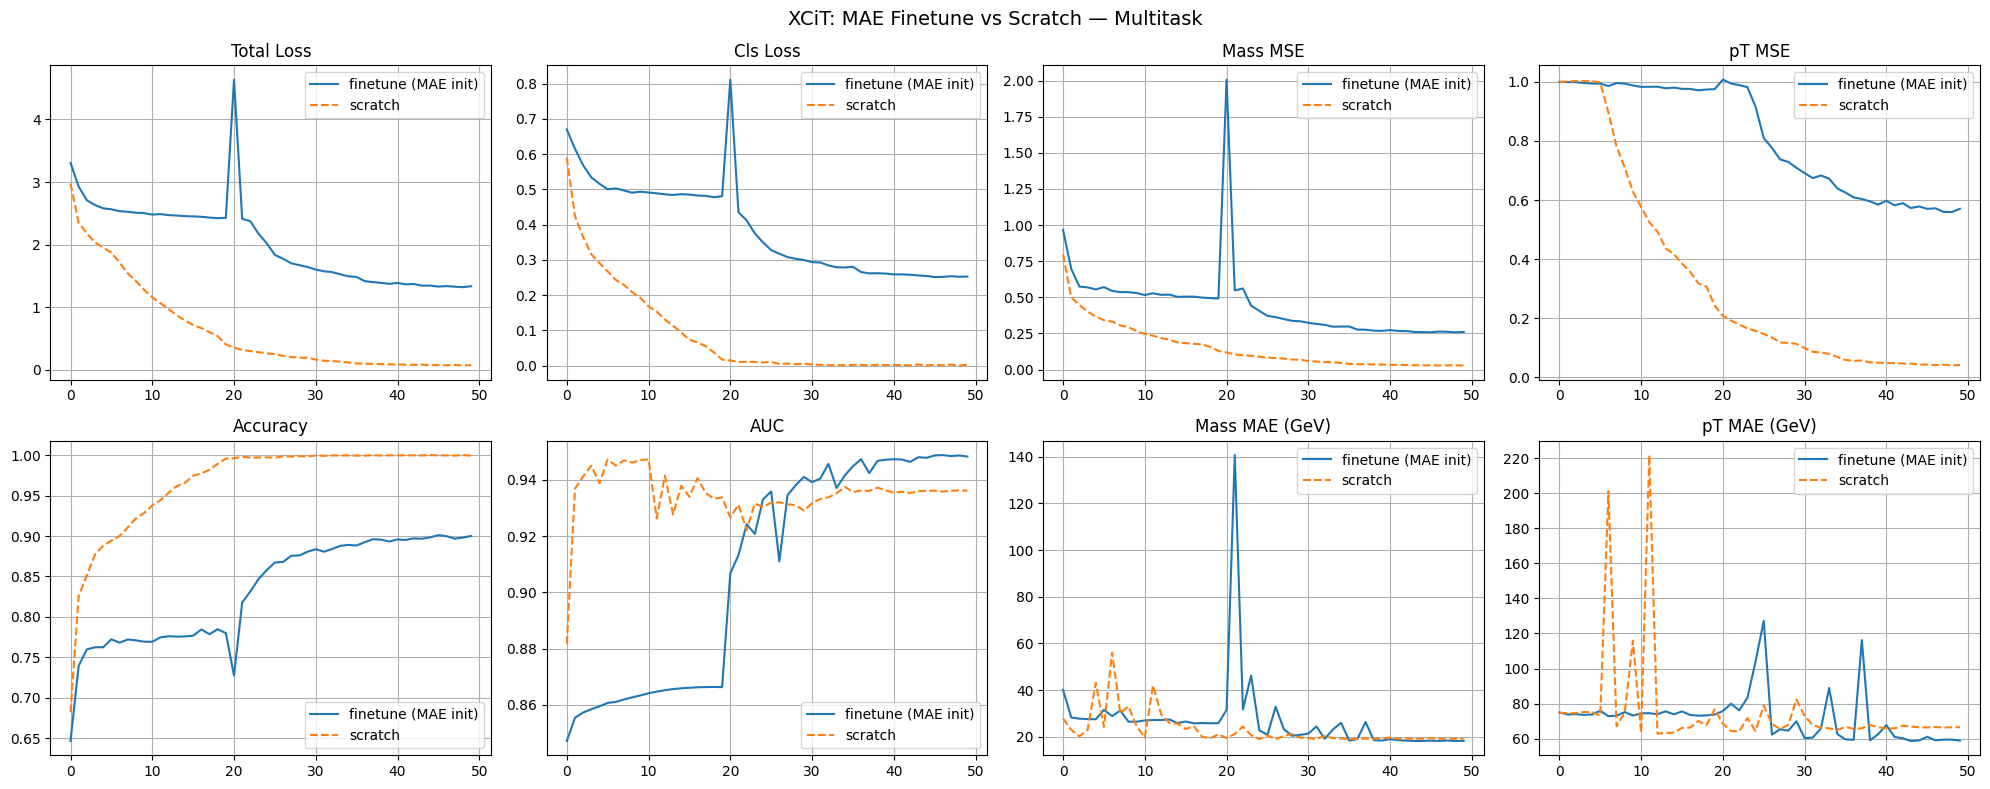

In [15]:
fig,axes=plt.subplots(2,4,figsize=(20,8))
metrics=["loss","cls","mass_mse","pt_mse","acc","auc","mass_mae","pt_mae"]
titles=["Total Loss","Cls Loss","Mass MSE","pT MSE","Accuracy","AUC","Mass MAE (GeV)","pT MAE (GeV)"]
for ax,m,title in zip(axes.flat,metrics,titles):
    ax.plot(hist_ft[m],label="finetune (MAE init)")
    ax.plot(hist_sc[m],label="scratch",linestyle="--")
    ax.set_title(title); ax.legend(); ax.grid(True)
plt.suptitle("XCiT: MAE Finetune vs Scratch — Multitask",fontsize=14)
plt.tight_layout()
plt.savefig("xcit_mt_curves.png",dpi=150); plt.show()


## 16 · Regression Scatter Plots

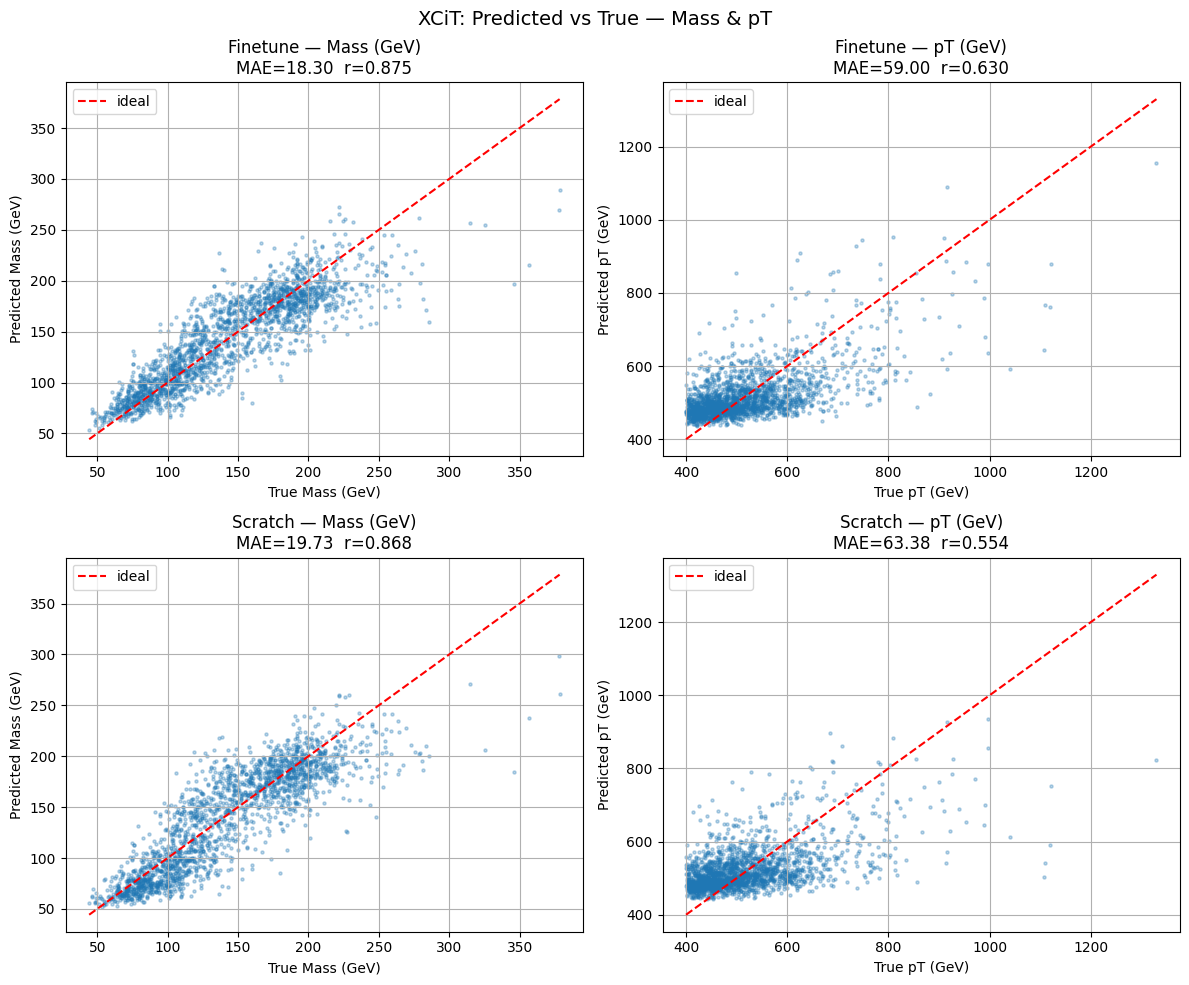

In [16]:
fig,axes=plt.subplots(2,2,figsize=(12,10))
for ax,(pred,true,label,mname) in zip(axes.flat,[
    (mp_ft,mt_ft,"Mass (GeV)","Finetune"),
    (pp_ft,pt_ft,"pT (GeV)","Finetune"),
    (mp_sc,mt_sc,"Mass (GeV)","Scratch"),
    (pp_sc,pt_sc,"pT (GeV)","Scratch")]):
    ax.scatter(true,pred,alpha=0.3,s=5)
    lims=[min(true.min(),pred.min()),max(true.max(),pred.max())]
    ax.plot(lims,lims,"r--",linewidth=1.5,label="ideal")
    ax.set_xlabel(f"True {label}"); ax.set_ylabel(f"Predicted {label}")
    mae=np.abs(pred-true).mean(); r=np.corrcoef(true,pred)[0,1]
    ax.set_title(f"{mname} — {label}\nMAE={mae:.2f}  r={r:.3f}")
    ax.legend(); ax.grid(True)
plt.suptitle("XCiT: Predicted vs True — Mass & pT",fontsize=14)
plt.tight_layout()
plt.savefig("xcit_mt_regression.png",dpi=150); plt.show()


## 17 · Q/K Norm Saliency — Finetuned Model
Which patches does the finetuned XCiT attend to?
Uses ℓ₂-norms of Q and K in the last XCA layer as a saliency proxy (XCiT Appendix D.5).

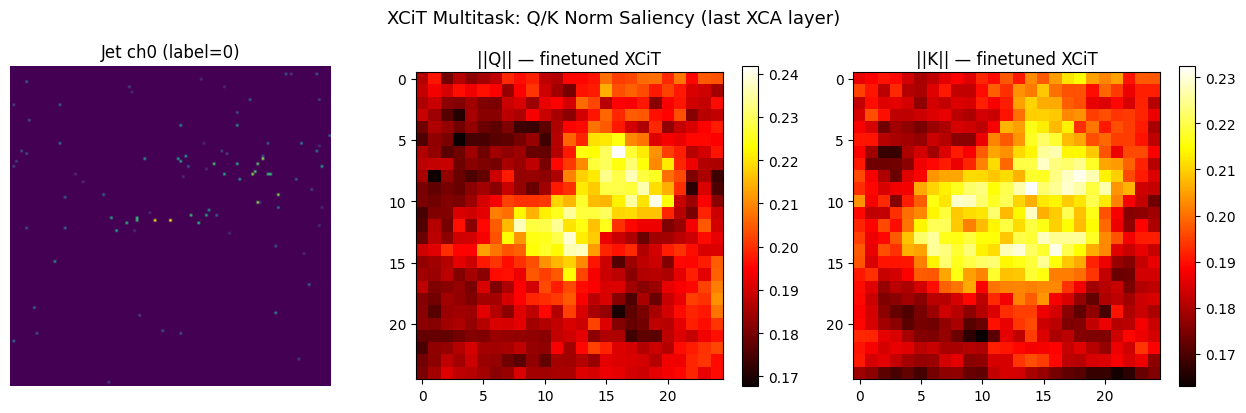

In [17]:
@torch.no_grad()
def xcit_saliency(model, img_tensor):
    model.eval()
    x=img_tensor.to(DEVICE); ps=model.patch_size
    pad_h=(ps-x.shape[2]%ps)%ps; pad_w=(ps-x.shape[3]%ps)%ps
    if pad_h or pad_w: x=F.pad(x,(0,pad_w,0,pad_h))
    H=x.shape[2]//ps; W=x.shape[3]//ps
    xf=model.patch_embed(x).flatten(2).transpose(1,2).contiguous()
    xf=model.emb_norm(xf+model.pos_emb(H,W,x.device).unsqueeze(0))
    for blk in model.blocks[:-1]: xf=blk(xf,H,W)
    last=model.blocks[-1]; h=last.xca.num_heads
    xn=last.norm1(xf); B2,N,C=xn.shape
    qkv=last.xca.qkv(xn).reshape(B2,N,3,h,C//h).permute(2,0,3,1,4).contiguous()
    q,k=qkv[0],qkv[1]
    q_t=F.normalize(q.transpose(-2,-1).contiguous(),dim=-1,p=2)
    k_t=F.normalize(k.transpose(-2,-1).contiguous(),dim=-1,p=2)
    q_norm=q_t.norm(dim=2).mean(1).squeeze(0).cpu().numpy()
    k_norm=k_t.norm(dim=2).mean(1).squeeze(0).cpu().numpy()
    return q_norm.reshape(H,W), k_norm.reshape(H,W)

model_ft.load_state_dict(torch.load("best_xcit_mt_ft.pth",map_location=DEVICE))
sample_t=torch.from_numpy(X_test[0:1]).float().permute(0,3,1,2)
q_map,k_map=xcit_saliency(model_ft,sample_t)

fig,ax=plt.subplots(1,3,figsize=(13,4))
ax[0].imshow(X_test[0,:,:,0],cmap="viridis"); ax[0].set_title(f"Jet ch0 (label={y_test[0]})"); ax[0].axis("off")
im1=ax[1].imshow(q_map,cmap="hot"); ax[1].set_title("||Q|| — finetuned XCiT"); plt.colorbar(im1,ax=ax[1])
im2=ax[2].imshow(k_map,cmap="hot"); ax[2].set_title("||K|| — finetuned XCiT"); plt.colorbar(im2,ax=ax[2])
plt.suptitle("XCiT Multitask: Q/K Norm Saliency (last XCA layer)",fontsize=13)
plt.tight_layout(); plt.savefig("xcit_mt_saliency.png",dpi=150); plt.show()
